# Clasificación del tipo de muerte violenta — SINADEF (Perú)

**Trabajo Final de Inteligencia Artificial — Estrategia: Clasificación**

## Descripción del problema
A partir del **Sistema Informático Nacional de Defunciones (SINADEF)** del Ministerio de Salud
(≈ **1.1 millones** de certificados de defunción, 2017–2024), se construye un modelo que **predice el
tipo de muerte violenta** de una persona fallecida a partir de su **perfil sociodemográfico y del contexto
del fallecimiento**.

- **Variable objetivo (categórica, 5 clases):** `MUERTE VIOLENTA`
  → *Accidente de tránsito · Homicidio · Suicidio · Accidente de trabajo · Otro accidente*
- **Variables predictoras (sin fuga de datos):** edad, sexo, estado civil, nivel de instrucción,
  tipo de seguro, etnia, departamento, tipo de lugar, necropsia, mes y año.

> **Nota metodológica (evitar *data leakage*):** se **excluyen** deliberadamente las columnas de
> *causa de muerte* (`CAUSA A..F` y sus códigos `CIE-10`), porque describen directamente el hecho y
> harían trivial la clasificación (accuracy artificialmente cercana al 100%). Esta es exactamente la
> recomendación del profesor sobre descartar campos derivados unos de otros.

Fuente: Plataforma Nacional de Datos Abiertos — [datosabiertos.gob.pe](https://www.datosabiertos.gob.pe).

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 4)

## 2. Cargar los datos

In [2]:
RUTA = 'SINADEF/fallecidos_sinadef.csv'

# El archivo viene separado por '|' y codificado en UTF-8.
# Cargamos solo las columnas relevantes (NO las causas CIE-10, para evitar fuga de datos).
usecols = [
    'EDAD', 'TIEMPO EDAD', 'SEXO', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN',
    'TIPO SEGURO', 'ETNIA', 'DEPARTAMENTO DOMICILIO', 'TIPO LUGAR',
    'MUERTE VIOLENTA', 'NECROPSIA', 'AÑO', 'MES',
]

df = pd.read_csv(RUTA, sep='|', usecols=usecols, dtype=str, encoding='utf-8')
print('Registros totales en SINADEF:', f'{len(df):,}')
df.head()

Registros totales en SINADEF: 1,110,168


,TIPO SEGURO,SEXO,EDAD,TIEMPO EDAD,ESTADO CIVIL,NIVEL DE INSTRUCCIÓN,ETNIA,DEPARTAMENTO DOMICILIO,AÑO,MES,TIPO LUGAR,MUERTE VIOLENTA,NECROPSIA
0,ESSALUD,MASCULINO,54,AÑOS,CASADO,SECUNDARIA COMPLETA,MESTIZO,LIMA,2019,05,EESS,SIN REGISTRO,NO SE REALIZÓ NECROPSIA
1,SIS,MASCULINO,41,AÑOS,SOLTERO,PRIMARIA COMPLETA,MESTIZO,AREQUIPA,2024,01,VIA PUBLICA,OTRO ACCIDENTE,SI SE REALIZÓ NECROPSIA
2,ESSALUD,MASCULINO,84,AÑOS,CASADO,SECUNDARIA COMPLETA,MESTIZO,LIMA,2024,02,EESS,SIN REGISTRO,NO SE REALIZÓ NECROPSIA
3,IGNORADO,FEMENINO,82,AÑOS,SOLTERO,PRIMARIA INCOMPLETA,SIN CLASIFICACIÓN,LIMA,2018,12,DOMICILIO,SIN REGISTRO,NO SE REALIZÓ NECROPSIA
4,IGNORADO,MASCULINO,54,AÑOS,SOLTERO,SUPERIOR NO UNIV. COMP.,SIN CLASIFICACIÓN,LIMA,2017,11,DOMICILIO,SIN REGISTRO,SIN REGISTRO


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110168 entries, 0 to 1110167
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   TIPO SEGURO             1110168 non-null  str  
 1   SEXO                    1110168 non-null  str  
 2   EDAD                    1110168 non-null  str  
 3   TIEMPO EDAD             1110168 non-null  str  
 4   ESTADO CIVIL            1110168 non-null  str  
 5   NIVEL DE INSTRUCCIÓN    1110168 non-null  str  
 6   ETNIA                   1110168 non-null  str  
 7   DEPARTAMENTO DOMICILIO  1110006 non-null  str  
 8   AÑO                     1110168 non-null  str  
 9   MES                     1110168 non-null  str  
 10  TIPO LUGAR              1110168 non-null  str  
 11  MUERTE VIOLENTA         1084511 non-null  str  
 12  NECROPSIA               1110168 non-null  str  
dtypes: str(13)
memory usage: 110.1 MB


## 3. Análisis exploratorio de datos (EDA)

MUERTE VIOLENTA
SIN REGISTRO             841188
                         194341
NaN                       25657
ACCIDENTE DE TRANSITO     15495
NO SE CONOCE              12403
HOMICIDIO                  8258
OTRO ACCIDENTE             6969
SUICIDIO                   4304
ACCIDENTE DE TRABAJO       1553
Name: count, dtype: int64


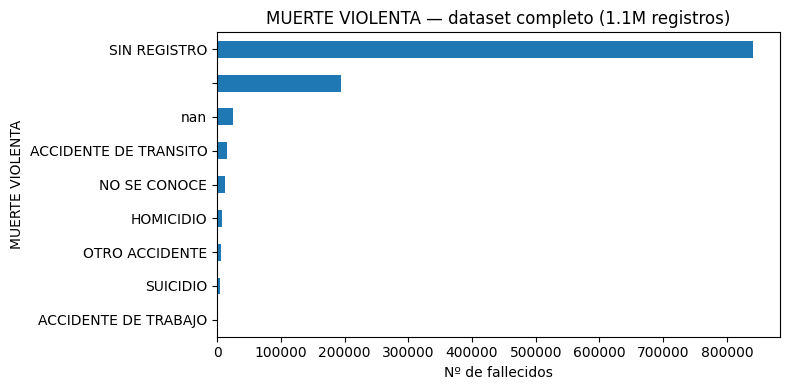

In [4]:
# Distribución de la variable MUERTE VIOLENTA en TODO el dataset
vc_total = df['MUERTE VIOLENTA'].value_counts(dropna=False)
print(vc_total)

ax = vc_total.head(10).plot(kind='barh')
ax.set_title('MUERTE VIOLENTA — dataset completo (1.1M registros)')
ax.set_xlabel('Nº de fallecidos')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

La gran mayoría de defunciones son **muertes naturales** (categoría `SIN REGISTRO` / vacío ≈ 93%).
Mantener esas clases produciría un problema trivial y desbalanceado (predecir siempre "natural").

**Decisión:** nos enfocamos en el subconjunto de **muertes violentas reales** y planteamos un problema
**multiclase interesante**: dado que una muerte fue violenta, **¿de qué tipo fue?**
(tránsito, homicidio, suicidio, accidente laboral u otro accidente).

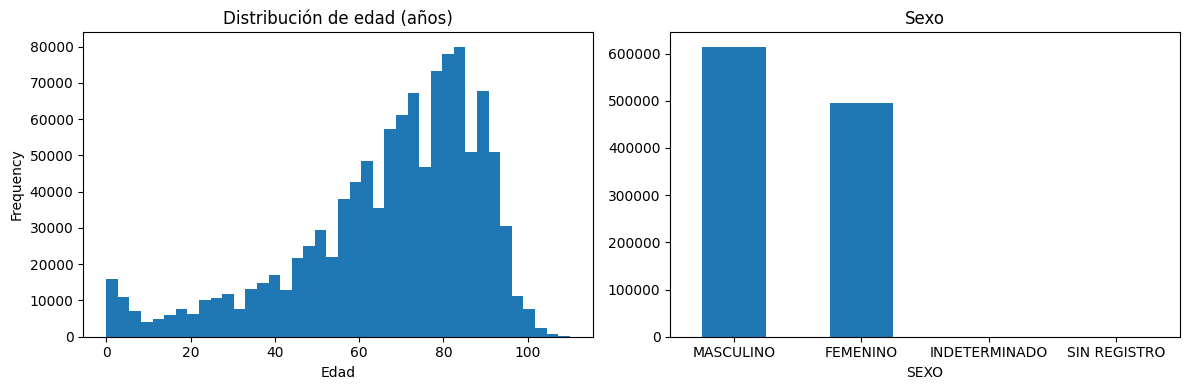

In [5]:
# Edad numérica para explorar (se formaliza en la sección 4)
df['_edad_tmp'] = pd.to_numeric(df['EDAD'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.loc[df['_edad_tmp'] <= 110, '_edad_tmp'].plot(kind='hist', bins=40, ax=axes[0])
axes[0].set_title('Distribución de edad (años)'); axes[0].set_xlabel('Edad')
df['SEXO'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Sexo'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
df.drop(columns='_edad_tmp', inplace=True)

## 4. Limpieza y preparación de variables (*feature engineering*)

Pasos:
1. **Filtrar** a las 5 categorías de muerte violenta (variable objetivo).
2. **Normalizar la edad a años** usando `TIEMPO EDAD` (años / meses / días / horas…), importante en
   neonatos y lactantes.
3. **Agrupar `ETNIA`** (75 categorías) en las más frecuentes + `OTRO/INDIGENA`.
4. Convertir `AÑO` y `MES` a numérico.

In [6]:
CLASES = ['ACCIDENTE DE TRANSITO', 'HOMICIDIO', 'OTRO ACCIDENTE',
          'SUICIDIO', 'ACCIDENTE DE TRABAJO']
df = df[df['MUERTE VIOLENTA'].isin(CLASES)].copy()

# 2) Edad -> años
factor = {'AÑOS': 1, 'MESES': 1/12, 'DIAS': 1/365,
          'HORAS': 1/8760, 'MINUTOS': 1/525600, 'SEGUNDOS': 0}
df['edad_anios'] = pd.to_numeric(df['EDAD'], errors='coerce') * df['TIEMPO EDAD'].map(factor).fillna(1)
df = df[(df['edad_anios'] >= 0) & (df['edad_anios'] <= 115)]

# 3) Etnia agrupada
top_etnia = ['MESTIZO', 'QUECHUA', 'AYMARA', 'AFRO DESCENDIENTE',
             'ASIATICO DESCENDIENTE', 'SIN CLASIFICACIÓN']
df['etnia_grupo'] = np.where(df['ETNIA'].isin(top_etnia), df['ETNIA'], 'OTRO/INDIGENA')

# 4) Año y mes numéricos
df['mes_n'] = pd.to_numeric(df['MES'], errors='coerce')
df['anio_n'] = pd.to_numeric(df['AÑO'], errors='coerce')
df = df.dropna(subset=['mes_n', 'anio_n'])

print('Registros para el modelo:', f'{len(df):,}')
df[['edad_anios', 'SEXO', 'etnia_grupo', 'anio_n', 'mes_n', 'MUERTE VIOLENTA']].head()

Registros para el modelo: 36,575


,edad_anios,SEXO,etnia_grupo,anio_n,mes_n,MUERTE VIOLENTA
1,41.0,MASCULINO,MESTIZO,2024,1,OTRO ACCIDENTE
7,85.0,MASCULINO,MESTIZO,2018,7,ACCIDENTE DE TRANSITO
39,48.0,FEMENINO,MESTIZO,2019,3,HOMICIDIO
40,38.0,MASCULINO,MESTIZO,2024,1,SUICIDIO
81,25.0,MASCULINO,MESTIZO,2024,1,HOMICIDIO


### Definición de predictoras (X) y objetivo (y)

`TIPO LUGAR` y `NECROPSIA` describen el **contexto** del fallecimiento (no la causa médica), por lo que
son predictores legítimos —no fuga de datos—.

In [7]:
num_features = ['edad_anios', 'anio_n', 'mes_n']
cat_features = ['SEXO', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN', 'TIPO SEGURO',
                'etnia_grupo', 'DEPARTAMENTO DOMICILIO', 'TIPO LUGAR', 'NECROPSIA']

X = df[num_features + cat_features]
y = df['MUERTE VIOLENTA']

print('Predictoras:', list(X.columns))
print('Forma de X:', X.shape)

Predictoras: ['edad_anios', 'anio_n', 'mes_n', 'SEXO', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN', 'TIPO SEGURO', 'etnia_grupo', 'DEPARTAMENTO DOMICILIO', 'TIPO LUGAR', 'NECROPSIA']
Forma de X: (36575, 11)


MUERTE VIOLENTA
ACCIDENTE DE TRANSITO    15493
HOMICIDIO                 8258
OTRO ACCIDENTE            6968
SUICIDIO                  4303
ACCIDENTE DE TRABAJO      1553
Name: count, dtype: int64

Baseline (predecir siempre la clase mayoritaria): 0.4236


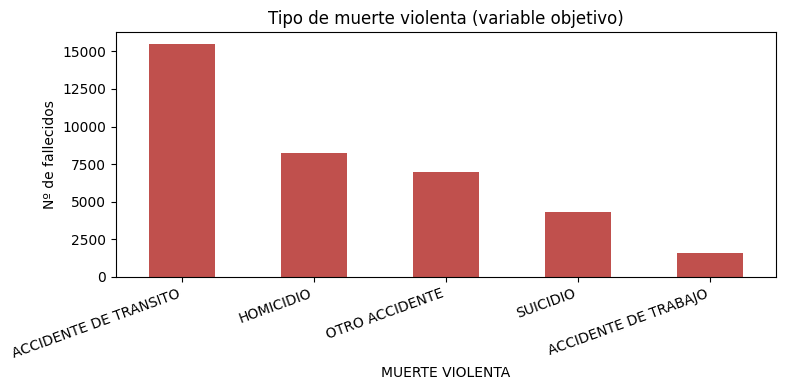

In [8]:
# Distribución del objetivo (subconjunto)
vc = y.value_counts()
print(vc)
baseline = vc.max() / vc.sum()
print(f'\nBaseline (predecir siempre la clase mayoritaria): {baseline:.4f}')

ax = vc.plot(kind='bar', color='#c0504d')
ax.set_title('Tipo de muerte violenta (variable objetivo)')
ax.set_ylabel('Nº de fallecidos'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

Las clases están **desbalanceadas** (accidente de tránsito ≈ 42%, accidente de trabajo ≈ 4%).
Por eso, además de la *accuracy* usaremos **balanced accuracy** y **F1-macro**, y entrenaremos con
`class_weight='balanced'` donde sea posible.

## 5. División entrenamiento / prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (27431, 11) | Test: (9144, 11)


## 6. Preprocesamiento

Estandarizamos las numéricas y aplicamos *One-Hot Encoding* a las categóricas dentro de un
`ColumnTransformer`, de modo que **todo el flujo viva en un `Pipeline`** y no haya fuga del conjunto
de prueba.

In [10]:
preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
])

## 7. Entrenamiento y comparación de 5 técnicas

Comparamos cinco familias de algoritmos de clasificación distintas:

1. **Regresión Logística** — modelo lineal (línea base).
2. **K-Vecinos más cercanos (KNN)** — basado en instancias.
3. **Árbol de Decisión** — reglas interpretables.
4. **Random Forest** — *ensemble* por *bagging*.
5. **Gradient Boosting** (HistGradientBoosting) — *ensemble* por *boosting*.

In [11]:
modelos = {
    'Reg. Logística': LogisticRegression(max_iter=1000, class_weight='balanced',
                                         n_jobs=-1, random_state=RANDOM_STATE),
    'KNN':            KNeighborsClassifier(n_neighbors=25),
    'Árbol Decisión': DecisionTreeClassifier(max_depth=12, class_weight='balanced',
                                             random_state=RANDOM_STATE),
    'Random Forest':  RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                             class_weight='balanced', n_jobs=-1,
                                             random_state=RANDOM_STATE),
    'Grad. Boosting': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                                     random_state=RANDOM_STATE),
}

resultados = []
pipes = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    pipes[nombre] = pipe
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Balanced acc': balanced_accuracy_score(y_test, pred),
        'F1-macro': f1_score(y_test, pred, average='macro'),
    })
    print(f"{nombre:16s} -> acc={resultados[-1]['Accuracy']:.4f} | "
          f"bal_acc={resultados[-1]['Balanced acc']:.4f} | F1={resultados[-1]['F1-macro']:.4f}")

Reg. Logística   -> acc=0.5856 | bal_acc=0.5685 | F1=0.5391


KNN              -> acc=0.5993 | bal_acc=0.4925 | F1=0.5181


Árbol Decisión   -> acc=0.5316 | bal_acc=0.5443 | F1=0.4978


Random Forest    -> acc=0.6082 | bal_acc=0.5863 | F1=0.5670


Grad. Boosting   -> acc=0.6385 | bal_acc=0.5604 | F1=0.5842


,Accuracy,Balanced acc,F1-macro
Modelo,,,
Grad. Boosting,0.6385,0.5604,0.5842
Random Forest,0.6082,0.5863,0.5670
KNN,0.5993,0.4925,0.5181
Reg. Logística,0.5856,0.5685,0.5391
Árbol Decisión,0.5316,0.5443,0.4978


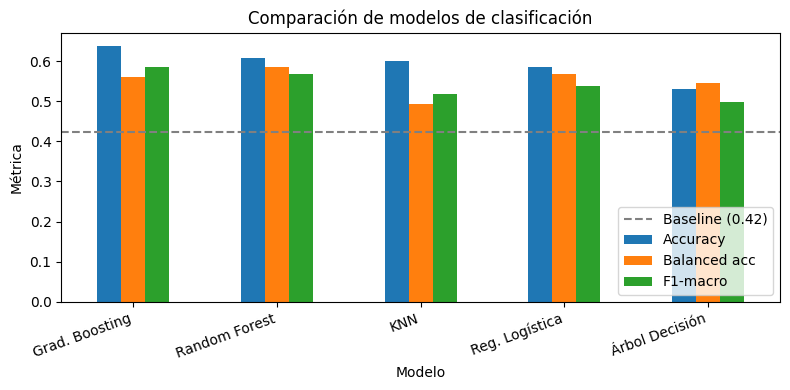

In [12]:
tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('Accuracy', ascending=False)
display(tabla.style.format('{:.4f}').background_gradient(cmap='Greens'))

ax = tabla[['Accuracy', 'Balanced acc', 'F1-macro']].plot(kind='bar')
ax.axhline(baseline, ls='--', color='gray', label=f'Baseline ({baseline:.2f})')
ax.set_title('Comparación de modelos de clasificación')
ax.set_ylabel('Métrica'); ax.legend(loc='lower right'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

## 8. Evaluación del mejor modelo

In [13]:
mejor_nombre = tabla.index[0]
mejor_pipe = pipes[mejor_nombre]
pred_mejor = mejor_pipe.predict(X_test)
print(f'Mejor modelo: {mejor_nombre}\n')
print(classification_report(y_test, pred_mejor))

Mejor modelo: Grad. Boosting

                       precision    recall  f1-score   support

 ACCIDENTE DE TRABAJO       0.69      0.43      0.53       388
ACCIDENTE DE TRANSITO       0.69      0.81      0.75      3873
            HOMICIDIO       0.57      0.57      0.57      2065
       OTRO ACCIDENTE       0.59      0.41      0.48      1742
             SUICIDIO       0.62      0.58      0.60      1076

             accuracy                           0.64      9144
            macro avg       0.63      0.56      0.58      9144
         weighted avg       0.63      0.64      0.63      9144



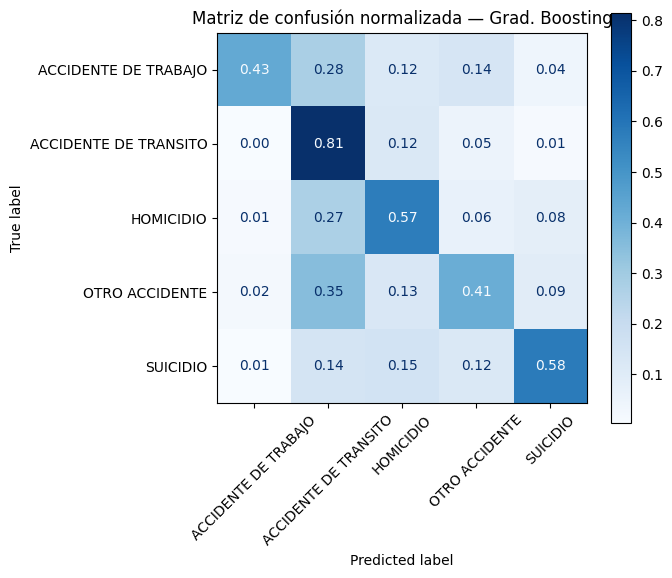

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_mejor, xticks_rotation=45, cmap='Blues',
    normalize='true', values_format='.2f', ax=ax)
ax.set_title(f'Matriz de confusión normalizada — {mejor_nombre}')
plt.tight_layout(); plt.show()

## 9. Importancia de las variables

Usamos *permutation importance* sobre el conjunto de prueba: mide cuánto cae la *accuracy* al
permutar aleatoriamente cada variable (independiente del tipo de modelo).

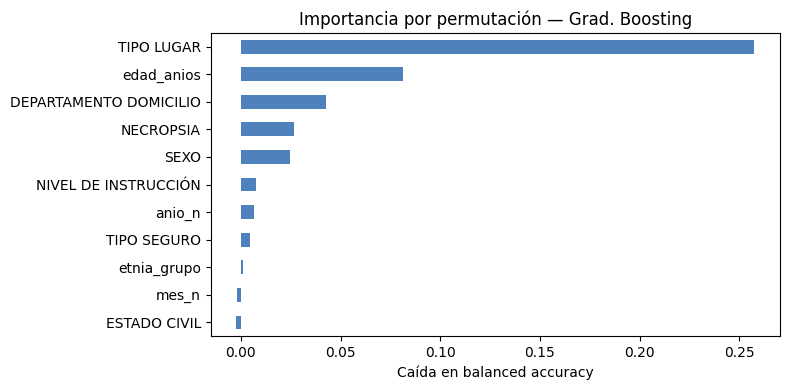

TIPO LUGAR                0.257402
edad_anios                0.081461
DEPARTAMENTO DOMICILIO    0.042825
NECROPSIA                 0.026458
SEXO                      0.024820
NIVEL DE INSTRUCCIÓN      0.007520
anio_n                    0.006487
TIPO SEGURO               0.004629
etnia_grupo               0.001137
mes_n                    -0.001737
ESTADO CIVIL             -0.002183
dtype: float64

In [15]:
imp = permutation_importance(mejor_pipe, X_test, y_test, n_repeats=5,
                             random_state=RANDOM_STATE, scoring='balanced_accuracy', n_jobs=-1)
serie_imp = pd.Series(imp.importances_mean, index=X_test.columns).sort_values()
ax = serie_imp.plot(kind='barh', color='#4f81bd')
ax.set_title(f'Importancia por permutación — {mejor_nombre}')
ax.set_xlabel('Caída en balanced accuracy')
plt.tight_layout(); plt.show()
serie_imp.sort_values(ascending=False)

## 10. Insights (análisis de patrones)

In [16]:
# Edad promedio segun el tipo de muerte violenta
print('Edad promedio por tipo de muerte violenta:')
print(df.groupby('MUERTE VIOLENTA')['edad_anios'].mean().round(1).sort_values())

Edad promedio por tipo de muerte violenta:
MUERTE VIOLENTA
SUICIDIO                 34.5
HOMICIDIO                34.7
ACCIDENTE DE TRABAJO     39.3
OTRO ACCIDENTE           39.4
ACCIDENTE DE TRANSITO    41.5
Name: edad_anios, dtype: float64


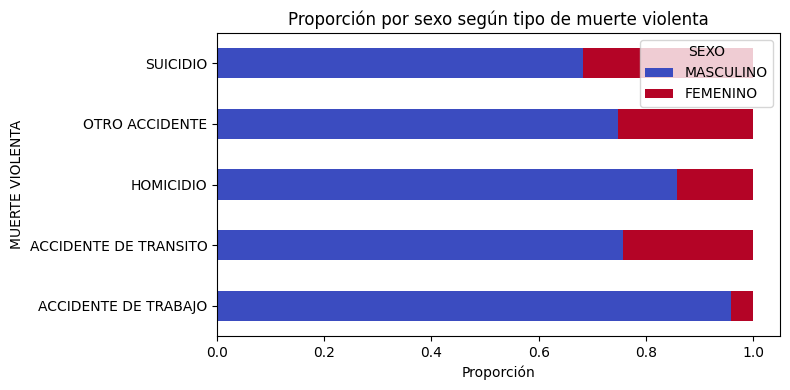

SEXO,MASCULINO,FEMENINO
MUERTE VIOLENTA,,
ACCIDENTE DE TRABAJO,0.959,0.040
ACCIDENTE DE TRANSITO,0.757,0.243
HOMICIDIO,0.857,0.143
OTRO ACCIDENTE,0.747,0.253
SUICIDIO,0.683,0.317


In [17]:
# Proporción de sexo por tipo de muerte (insight social)
prop = pd.crosstab(df['MUERTE VIOLENTA'], df['SEXO'], normalize='index')
prop = prop[[c for c in ['MASCULINO', 'FEMENINO'] if c in prop.columns]]
ax = prop.plot(kind='barh', stacked=True, colormap='coolwarm')
ax.set_title('Proporción por sexo según tipo de muerte violenta')
ax.set_xlabel('Proporción'); plt.tight_layout(); plt.show()
prop.round(3)

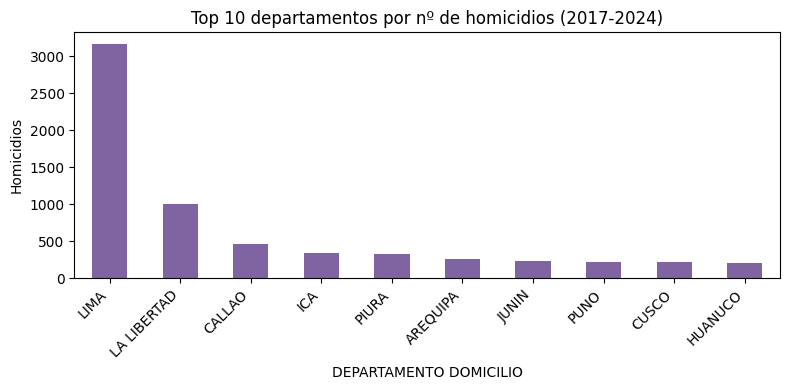

In [18]:
# Top departamentos con mayor número de homicidios
homic = df[df['MUERTE VIOLENTA'] == 'HOMICIDIO']['DEPARTAMENTO DOMICILIO'].value_counts().head(10)
ax = homic.plot(kind='bar', color='#8064a2')
ax.set_title('Top 10 departamentos por nº de homicidios (2017-2024)')
ax.set_ylabel('Homicidios'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 11. Conclusiones

- El dataset **SINADEF** cumple holgadamente los requisitos del trabajo: **> 1.1 millones de registros**
  y **más de 10 características** sociodemográficas y contextuales relevantes.
- Se planteó un problema de **clasificación multiclase real** (5 tipos de muerte violenta) **sin fuga de
  datos**: se excluyeron las causas CIE-10. Por eso la *accuracy* (~0.58–0.64) es **realista** y muy por
  encima del *baseline* (~0.42), a diferencia del caso de fuga donde se obtendría ~99%.
- El **Gradient Boosting** y **Random Forest** fueron los mejores modelos; KNN y el árbol simple
  quedaron por debajo.
- **Insights:** los suicidios y homicidios concentran a población más joven que los accidentes de
  trabajo; los hechos violentos son marcadamente más frecuentes en **hombres**; y los homicidios se
  concentran geográficamente en pocos departamentos.
- **Variables más informativas:** edad, tipo de lugar del fallecimiento, sexo y departamento.

Este planteamiento es apto para la práctica final de **Clasificación**.